## Quant Accelerator Course

### Structure
Input -> Model -> Prediction -> Strategy -> Orders -> Execution

1) **Model** takes an **input**
2) **Model** makes a **prediction** into the future, also called **forecast**
3) The **strategy** takes the prediction and converts it into **orders**
4) **Orders** are then **executed** into a broker platform or an exchange

## Exercise Calculate Price Delta

In [1]:
price_today = 100.0
price_yesterday = 90.0
price_delta = abs(price_today - price_yesterday)
price_delta

10.0

In [2]:
price_delta == 10

True

### Numpy Arrays

In [3]:
import numpy as np

n = 100000000
a = np.ones(n) # Create a large array of ones
len(a)

100000000

### Difference between Python Standard Arrays and NumPy Arrays

In [4]:
%%time

# This will be much faster than the built-in sum() function, which is not optimized for large arrays.
# NumPy's sum() function is implemented in C and can take advantage of SIMD instructions and multi-threading
# using homogeneous data types, which is the case for NumPy arrays.
np.sum(a)

CPU times: total: 109 ms
Wall time: 114 ms


np.float64(100000000.0)

In [5]:
%%time
sum(a)

CPU times: total: 5.59 s
Wall time: 5.62 s


np.float64(100000000.0)

### Logarithm (log)

In [6]:
np.exp(2) # Exponential of 2

np.float64(7.38905609893065)

In [7]:
np.log(np.exp(2)) # It tells you the exponent that you need to raise e to in order to get 2

np.float64(2.0)

### Invest $1000 at a continuous rate of 5% per year

In [8]:
1000 * 1.05 # First year return

1050.0

In [9]:
1000 * 1.05 * 1.05 #Second year return

1102.5

In [10]:
%%time

# First brute-force way of calculating annual rates
trade_years = 20
capital = 1000
rate = 1.05
for _ in range(trade_years):
    capital *= rate
capital

CPU times: total: 0 ns
Wall time: 19.1 μs


2653.2977051444223

In [11]:
%%time

# Analytical Solution, one line, faster
1000 * 1.05 ** 20

CPU times: total: 0 ns
Wall time: 6.44 μs


2653.2977051444223

### How long to double our investment

In [12]:
capital = 1000 # $1000
t = 1          # 1 Year

# 2 * capital == capital * 1.05 ** t
# 2 == 1.05 ** t
# np.log(2) == np.log(1.05) * t

t = np.log(2) / np.log(1.05)
t # about 14 years

np.float64(14.206699082890463)

In [13]:
# Double check

capital * 1.05 ** t == 2000.0

np.True_

### Why returns?

In [14]:
pnl = 100 # Profit and loss

pnl / 50.0 # Return on investment (ROI) is 200% because you made $100 on a $50 investment.
pnl / 99.0 # ROI is 101% because you made $100 on a $99 investment.

# Working with returns instead of prices is often more convenient, especially when comparing different assets or strategies.
# It tells you how much the investment can scale by to reach a certain target
# which is more intuitive than working with absolute price changes.

1.0101010101010102

### Log Returns

In [15]:
portfolio = [100, 120, 100] # Porfolio value at different time points
deltas = [120 - 100, 100 - 120] # Absolute price changes
deltas

[20, -20]

In [16]:
# Here there is an asymmetric relationship between the price changes and the returns. 
# A $20 increase from $100 to $120 is a 20% return, while a $20 decrease from $120 to $100 is a -16.67% return. 
# This is because the return is calculated as the change in price divided by the original price,
# which leads to different percentages for the same absolute change depending on the starting point.

returns = [20 / 100, -20 / 120] # Returns corresponding to the price changes    
returns

[0.2, -0.16666666666666666]

In [17]:
# By using logarithmic returns, we can capture the percentage change in a unitless and symmetric way
# which is particularly useful for financial analysis and comparisons across different assets or time periods.

log_returns = [np.log(120 / 100), np.log(100 / 120)] # Log returns corresponding to the price changes
log_returns

[np.float64(0.1823215567939546), np.float64(-0.1823215567939546)]

### Exercise: Calculate Total Log Returns

In [18]:
portfolio = [100, 120, 100, 80, 155]
log_returns = []
for i in range(1, len(portfolio)):
    prev_value = portfolio[i - 1]
    curr_value = portfolio[i]
    log_returns.append(np.log(curr_value/prev_value))

log_returns

[np.float64(0.1823215567939546),
 np.float64(-0.1823215567939546),
 np.float64(-0.2231435513142097),
 np.float64(0.661398482245365)]

In [19]:
100 * np.exp(np.sum(log_returns)) == 155.0

np.True_

### Exercise: Calculate Comulative Log Returns

In [20]:
portfolio = [100, 120, 100, 80, 155]
cum_log_returns = []

for i in range(1, len(portfolio)):
    prev_value = portfolio[i - 1]
    curr_value = portfolio[i]

    prev_cum_log_returns = cum_log_returns[-1] if len(cum_log_returns) > 0.0 else 0.0

    cum_log_returns.append(prev_cum_log_returns + np.log(curr_value/prev_value))

cum_log_returns

[np.float64(0.1823215567939546),
 np.float64(0.0),
 np.float64(-0.2231435513142097),
 np.float64(0.4382549309311553)]

In [21]:
cum_log_returns == [np.log(120/100), np.log(120/100) + np.log(100/120), np.log(120/100) + np.log(100/120) + np.log(80 / 100), np.log(120/100) + np.log(100/120) + np.log(80 / 100) + np.log(155/80)]

True

### Vector Algebra

In [22]:
import numpy as np

class Vector:
    """
    A lightweight vector wrapper around NumPy arrays, providing
    elementwise arithmetic operations, statistics, and operator overloads.

    Parameters
    ----------
    data : array_like
        Input data to initialize the vector. Can be a list, tuple, or NumPy array.

    Attributes
    ----------
    data : np.ndarray
        The underlying NumPy array storing the vector elements.

    Examples
    --------
    >>> v = Vector([1, 2, 3])
    >>> v + 2
    Vector([3 4 5])
    >>> v * v
    Vector([1 4 9])
    >>> v.mean()
    2.0
    """

    data: np.ndarray

    def __init__(self, data) -> None:
        """Initialize the vector with the given data."""
        self.data = np.array(data)

    # ---------------------------------------------------------------------
    # Basic arithmetic methods
    # ---------------------------------------------------------------------
    def add(self, y) -> np.ndarray:
        """
        Add a scalar or array-like object to the vector.

        Parameters
        ----------
        y : array_like or scalar
            The value(s) to add.

        Returns
        -------
        np.ndarray
            Elementwise sum.
        """
        return self.data + y

    def sub(self, y) -> np.ndarray:
        """Subtract a scalar or array-like object from the vector."""
        return self.data - y

    def mul(self, y) -> np.ndarray:
        """Multiply the vector elementwise by a scalar or array-like object."""
        return self.data * y

    def div(self, y) -> np.ndarray:
        """Divide the vector elementwise by a scalar or array-like object."""
        return self.data / y

    # ---------------------------------------------------------------------
    # Statistical methods
    # ---------------------------------------------------------------------
    def sum(self):
        """
        Return the sum of all elements in the vector.

        Returns
        -------
        float
            The sum of all vector elements.
        """
        return np.sum(self.data)

    def mean(self):
        """
        Return the mean (average) of the vector elements.

        Returns
        -------
        float
            The mean of the vector elements.
        """
        return np.mean(self.data)

    def var(self):
        """
        Return the variance of the vector elements.

        Returns
        -------
        float
            The variance of the vector elements.
        """
        mu = self.mean()
        return np.mean((self.data - mu) ** 2)

    def std(self):
        """
        Return the standard deviation of the vector elements.

        Returns
        -------
        float
            The standard deviation of the vector elements.
        """
        return np.sqrt(self.var())

    def len(self):
        """
        Return the number of elements in the vector.

        Returns
        -------
        int
            Number of elements.
        """
        return len(self.data)

    # ---------------------------------------------------------------------
    # Operator overloads
    # ---------------------------------------------------------------------
    def __add__(self, other):
        """Implements self + other (elementwise addition)."""
        return Vector(self.data + self._to_array(other))

    def __sub__(self, other):
        """Implements self - other (elementwise subtraction)."""
        return Vector(self.data - self._to_array(other))

    def __mul__(self, other):
        """Implements self * other (elementwise multiplication)."""
        return Vector(self.data * self._to_array(other))

    def __truediv__(self, other):
        """Implements self / other (elementwise division)."""
        return Vector(self.data / self._to_array(other))

    def __radd__(self, other):
        """Implements other + self."""
        return self.__add__(other)

    def __rsub__(self, other):
        """Implements other - self."""
        return Vector(self._to_array(other) - self.data)

    def __rmul__(self, other):
        """Implements other * self."""
        return self.__mul__(other)

    def __rtruediv__(self, other):
        """Implements other / self."""
        return Vector(self._to_array(other) / self.data)

    def __pow__(self, power):
        """
        Implements self ** power (elementwise exponentiation).

        Parameters
        ----------
        power : float or int
            Exponent to which each element is raised.

        Returns
        -------
        Vector
            New vector with each element raised to the given power.
        """
        return Vector(self.data ** power)

    # ---------------------------------------------------------------------
    # Accessors
    # ---------------------------------------------------------------------
    def __getitem__(self, index):
        """
        Allow element or slice access via v[index].

        Parameters
        ----------
        index : int or slice
            Index or slice object.

        Returns
        -------
        scalar or Vector
            A single element (if int index) or a new Vector (if slice).
        """
        result = self.data[index]
        if isinstance(result, np.ndarray):
            return Vector(result)
        return result

    def __len__(self):
        """Return the number of elements in the vector (for len(v))."""
        return len(self.data)

    # ---------------------------------------------------------------------
    # Internal helpers and representation
    # ---------------------------------------------------------------------
    def _to_array(self, x):
        """
        Convert input to a NumPy array for arithmetic operations.

        Parameters
        ----------
        x : scalar, array_like, or Vector
            Input to convert.

        Returns
        -------
        np.ndarray
            NumPy array representation.
        """
        if isinstance(x, Vector):
            return x.data
        return np.array(x)

    def __repr__(self):
        """Return a string representation of the Vector."""
        return f"Vector({self.data})"


In [23]:
n = 100000000
v1 = [1 for _ in range(n)]
v2 = Vector(v1)

In [24]:
%%time
y = []
for x in v1:
    y.append(x + 1)
y[-10:]

CPU times: total: 9.19 s
Wall time: 9.32 s


[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [25]:
%%time

# This will be much faster than the loop, which is not optimized for large arrays.
# NumPy's elementwise operations are implemented in C and can take advantage of SIMD instructions and multi-threading
# using homogeneous data types, which is the case for NumPy arrays.

y = v2 + 1
y.data[-10:]

CPU times: total: 359 ms
Wall time: 354 ms


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Vectorized Statistics

In [26]:
log_returns = Vector([0.01, 0.015, 0.02, -0.01])
mu = log_returns.mean()
mu

np.float64(0.008749999999999999)

In [27]:
# The variance is calculated as the average of the squared differences from the mean.
((log_returns - mu) ** 2).mean()

np.float64(0.0001296875)

In [28]:
log_returns.var() == ((log_returns - mu) ** 2).mean()

np.True_

In [29]:
# Standard Deviation is calculated as the square root of the variance.
np.sqrt(log_returns.var())

np.float64(0.011388041973930374)

In [30]:
log_returns.std() == np.sqrt(log_returns.var())

np.True_

### Vectorized Sharpe Ratio

In [31]:
portfolio_log_returns = Vector([0.01, 0.01, 0.02, -0.01])
portfolio_log_returns.sum()

np.float64(0.03)

In [32]:
# In HFT and Intraday-Trading you do not factor Risk-Free rate because
# the time frame is so short that the risk-free rate has a negligible impact on the returns.
# The Sharpe Ratio is calculated as the mean return divided by the standard deviation of returns, 
# which gives you a measure of risk-adjusted return.

portfolio_log_returns.mean() / portfolio_log_returns.std()

np.float64(0.6882472016116852)

In [33]:
portfolio_log_returns = Vector([-0.01, -0.01, -0.01, 0.06])
portfolio_log_returns.sum()

np.float64(0.03)

In [34]:
# This Sharpe Ratio is significantly lower than the previous one. 
# Indicating that there's a much higher level of risk (volatility) relative to the returns,
# which is not favorable for an investment strategy.

portfolio_log_returns.mean() / portfolio_log_returns.std()

np.float64(0.24743582965269678)

### Building a Data Analysis Library

In [35]:
import numpy as np

class Column:
    """
    Column represents a single column of data, typically used in a tabular dataset.

    Each Column has a name and a vector of data (wrapped in a Vector object).
    Supports basic operations like length, sum, shift, division, and logarithm,
    and allows element-wise arithmetic with other Columns or scalars.
    """

    vec: 'Vector'

    def __init__(self, name, x):
        """
        Initialize a Column.

        Parameters
        ----------
        name : str
            The name of the column.
        x : list, np.ndarray, or Vector
            The data for the column.
        """
        self.vec = Vector(x)
        self.name = name

    def len(self):
        """
        Return the number of elements in the column.

        Returns
        -------
        int
            Length of the column vector.
        """
        return len(self.vec)

    def sum(self):
        """
        Compute the sum of all elements in the column.

        Returns
        -------
        float
            Sum of the column's elements.
        """
        return np.sum(self.vec)

    def shift(self, n=1):
        """
        Shift the column data downward by n positions, filling new entries with NaN.

        Parameters
        ----------
        n : int, optional
            Number of positions to shift (default is 1).

        Returns
        -------
        np.ndarray
            Shifted data as a NumPy array.
        """
        return np.concatenate(([np.nan] * n, self.vec[:-n]))

    def div(self, y) -> np.ndarray:
        """
        Divide the column element-wise by another Column or array-like object.

        Parameters
        ----------
        y : Column, Vector, or array-like
            The divisor.

        Returns
        -------
        np.ndarray
            Resulting element-wise division as a NumPy array.
        """
        if isinstance(y, Column):
            y = y.vec
        return self.vec / y

    def log(self):
        """
        Compute the natural logarithm of each element in the column.

        Returns
        -------
        np.ndarray
            Element-wise natural logarithm of the column.
        """
        return np.log(self.vec)

    def __truediv__(self, other) -> np.ndarray:
        """
        Enable the use of '/' operator for element-wise division.

        Parameters
        ----------
        other : Column, Vector, or array-like
            The divisor.

        Returns
        -------
        np.ndarray
            Element-wise division result.
        """
        return self.div(other)

    def __repr__(self):
        """
        Return a string representation of the column.

        Shows the first 10 elements of data and the column's name and length.

        Returns
        -------
        str
            Formatted string representation of the Column.
        """
        preview = ", ".join(map(str, self.vec[:10]))  # show first 10 items
        if len(self.vec) > 10:
            preview += ", ..."
        return f"Column(name='{self.name}', data=[{preview}], len={len(self.vec)})"


In [36]:
col = Column('trade_pnl', [2.0, -1.0, 3.0, 1.5])
col

Column(name='trade_pnl', data=[2.0, -1.0, 3.0, 1.5], len=4)

In [37]:
class DataFrame:
    """
    DataFrame: a simple tabular data structure.

    Maintains a list of Column objects in self.cols. Supports basic operations
    like length, adding columns, appending columns, and printing a formatted preview.
    """

    def __init__(self, cols):
        """
        Initialize the DataFrame.

        Parameters
        ----------
        cols : list
            A list of Column objects to initialize the DataFrame.
        """
        self.cols = cols

    def __len__(self):
        """
        Return the number of rows in the DataFrame.

        Returns
        -------
        int
            Number of rows. Assumes all columns have the same length.
        """
        return self.cols[0].len()

    def append(self, col):
        """
        Append a Column object to the DataFrame.

        Parameters
        ----------
        col : Column
            The Column object to append.
        """
        for i, c in enumerate(self.cols):
          if col.name == c.name:
            self.cols[i] = col
            return
        self.cols.append(col)

    def add_col(self, name, col):
        """
        Create a Column from name and data, and append it to the DataFrame.

        Parameters
        ----------
        name : str
            Name of the new column.
        col : list or np.ndarray
            Data for the new column.
        """
        self.cols.append(Column(name, col))

    def __getitem__(self, keys):
            """
            Select columns by name.

            Parameters
            ----------
            keys : str or list of str
                Column name(s) to select.

            Returns
            -------
            np.ndarray
                2D array with shape (n_rows, n_selected_columns)
            """
            if isinstance(keys, str):
                # Single column -> return 1D array
                for col in self.cols:
                    if col.name == keys:
                        return col.vec.data
                raise KeyError(f"Column '{keys}' not found.")
            elif isinstance(keys, list):
                # Multiple columns -> return 2D row-major array
                selected_cols = []
                for key in keys:
                    for col in self.cols:
                        if col.name == key:
                            selected_cols.append(col.vec)
                            break
                    else:
                        raise KeyError(f"Column '{key}' not found.")
                # Stack columns and transpose so rows are observations
                return np.column_stack(selected_cols)
            else:
                raise TypeError("Key must be a string or list of strings.")

    def __repr__(self):
        """
        Return a string representation of the DataFrame.

        Displays the first 10 rows of the DataFrame as a formatted table
        with column headers. If the DataFrame has more than 10 rows,
        adds "..." at the end to indicate more data.

        Returns
        -------
        str
            Formatted string table of the DataFrame preview.
        """
        col_names = [col.name for col in self.cols]

        # Determine width for each column (max of header or any value)
        col_widths = []
        preview_rows = min(len(self), 10)
        for col in self.cols:
            data_preview = [str(x) for x in col.vec[:preview_rows]]
            max_data_width = max(len(x) for x in data_preview) if data_preview else 0
            width = max(len(col.name), max_data_width)
            col_widths.append(width)

        # Format header row
        header = " | ".join(
            name.ljust(width) for name, width in zip(col_names, col_widths)
        )

        # Separator (column-aligned)
        separator = "-+-".join("-" * width for width in col_widths)

        # Format data rows
        rows = []
        for i in range(preview_rows):
            row = " | ".join(
                str(col.vec[i]).ljust(width) for col, width in zip(self.cols, col_widths)
            )
            rows.append(row)

        table = "\n".join([header, separator] + rows)
        if len(self) > 10:
            table += "\n..."
        return table


In [38]:
from datetime import datetime, timedelta

time = Column('time', [datetime(2025, 10, 1) + timedelta(days=i+1) for i in range(7)])
price = Column('price', [10.0, 11.0, 12.0, 10.0, 13.0, 14.0, 15.0])

table = DataFrame([time, price])
table

time                | price
--------------------+------
2025-10-02 00:00:00 | 10.0 
2025-10-03 00:00:00 | 11.0 
2025-10-04 00:00:00 | 12.0 
2025-10-05 00:00:00 | 10.0 
2025-10-06 00:00:00 | 13.0 
2025-10-07 00:00:00 | 14.0 
2025-10-08 00:00:00 | 15.0 

In [39]:
price_lag_1 = price.shift()
price_lag_1

array([nan, 10., 11., 12., 10., 13., 14.])

In [40]:
table.append(Column('price_lag_1', price_lag_1))
table

time                | price | price_lag_1
--------------------+-------+------------
2025-10-02 00:00:00 | 10.0  | nan        
2025-10-03 00:00:00 | 11.0  | 10.0       
2025-10-04 00:00:00 | 12.0  | 11.0       
2025-10-05 00:00:00 | 10.0  | 12.0       
2025-10-06 00:00:00 | 13.0  | 10.0       
2025-10-07 00:00:00 | 14.0  | 13.0       
2025-10-08 00:00:00 | 15.0  | 14.0       

In [41]:
# Price ratio
price.div(price_lag_1)

Vector([       nan 1.1        1.09090909 0.83333333 1.3        1.07692308
 1.07142857])

In [42]:
ratio = price.div(price_lag_1)
ratio_col = Column('ratio', ratio)
table.append(ratio_col)
table

time                | price | price_lag_1 | ratio             
--------------------+-------+-------------+-------------------
2025-10-02 00:00:00 | 10.0  | nan         | nan               
2025-10-03 00:00:00 | 11.0  | 10.0        | 1.1               
2025-10-04 00:00:00 | 12.0  | 11.0        | 1.0909090909090908
2025-10-05 00:00:00 | 10.0  | 12.0        | 0.8333333333333334
2025-10-06 00:00:00 | 13.0  | 10.0        | 1.3               
2025-10-07 00:00:00 | 14.0  | 13.0        | 1.0769230769230769
2025-10-08 00:00:00 | 15.0  | 14.0        | 1.0714285714285714

### Generate Auto-Regressive Log Returns

In [43]:
log_returns = ratio_col.log()
log_return_col = Column('log_return', log_returns)
table.append(log_return_col)
table

time                | price | price_lag_1 | ratio              | log_return         
--------------------+-------+-------------+--------------------+--------------------
2025-10-02 00:00:00 | 10.0  | nan         | nan                | nan                
2025-10-03 00:00:00 | 11.0  | 10.0        | 1.1                | 0.09531017980432493
2025-10-04 00:00:00 | 12.0  | 11.0        | 1.0909090909090908 | 0.08701137698962969
2025-10-05 00:00:00 | 10.0  | 12.0        | 0.8333333333333334 | -0.1823215567939546
2025-10-06 00:00:00 | 13.0  | 10.0        | 1.3                | 0.26236426446749106
2025-10-07 00:00:00 | 14.0  | 13.0        | 1.0769230769230769 | 0.07410797215372183
2025-10-08 00:00:00 | 15.0  | 14.0        | 1.0714285714285714 | 0.06899287148695142

In [44]:
# Auto Regressive model because log_return will be the 'Target'
# to be predicted off log_return_lag_1, the 'Feature'

log_return_lag_1_col = Column('log_return_lag_1', log_return_col.shift())
table.append(log_return_lag_1_col)
table

time                | price | price_lag_1 | ratio              | log_return          | log_return_lag_1   
--------------------+-------+-------------+--------------------+---------------------+--------------------
2025-10-02 00:00:00 | 10.0  | nan         | nan                | nan                 | nan                
2025-10-03 00:00:00 | 11.0  | 10.0        | 1.1                | 0.09531017980432493 | nan                
2025-10-04 00:00:00 | 12.0  | 11.0        | 1.0909090909090908 | 0.08701137698962969 | 0.09531017980432493
2025-10-05 00:00:00 | 10.0  | 12.0        | 0.8333333333333334 | -0.1823215567939546 | 0.08701137698962969
2025-10-06 00:00:00 | 13.0  | 10.0        | 1.3                | 0.26236426446749106 | -0.1823215567939546
2025-10-07 00:00:00 | 14.0  | 13.0        | 1.0769230769230769 | 0.07410797215372183 | 0.26236426446749106
2025-10-08 00:00:00 | 15.0  | 14.0        | 1.0714285714285714 | 0.06899287148695142 | 0.07410797215372183

### Matrices

#### Variables as Rows

This is a data-orientation choice: each row stores one variable across multiple observations. Here the first row is `x`, and the second row is `y`.

In [45]:
x = [1, 2, 3, 4]
y = [5, 1, 1, 1]

variables_as_rows = np.array([x, y])
variables_as_rows

array([[1, 2, 3, 4],
       [5, 1, 1, 1]])

In [46]:
x_row = variables_as_rows[0]
y_row = variables_as_rows[1]

# First column (index 0) gives the first observation across all variables
first_observation = variables_as_rows[:, 0] 

x_row, y_row, first_observation

(array([1, 2, 3, 4]), array([5, 1, 1, 1]), array([1, 5]))

#### Observations as Rows / Variables as Columns

This is the most common layout for machine learning and time series tables: each row is one observation, and each column is one variable or feature.

In [47]:
observations_as_rows = np.array([
    [1, 1],
    [2, 1],
    [3, 1],
    [4, 1],
])

observations_as_rows

array([[1, 1],
       [2, 1],
       [3, 1],
       [4, 1]])

In [48]:
first_row = observations_as_rows[0]
x_column = observations_as_rows[:, 0]
y_column = observations_as_rows[:, 1]

first_row, x_column, y_column

(array([1, 1]), array([1, 2, 3, 4]), array([1, 1, 1, 1]))

#### Row-Major vs Column-Major Memory Layout

Row-major and column-major describe how the same matrix is read or stored as a one-dimensional sequence in memory.

- Row-major order reads across each row first.
- Column-major order reads down each column first.

NumPy uses row-major order by default, also called C order. Column-major order is also called Fortran order.

In [49]:
layout_matrix = np.array([
    [1, 2],
    [3, 4],
])

row_major_order = layout_matrix.ravel(order="C")
column_major_order = layout_matrix.ravel(order="F")

layout_matrix, row_major_order, column_major_order

(array([[1, 2],
        [3, 4]]),
 array([1, 2, 3, 4]),
 array([1, 3, 2, 4]))

### Create Feature


In [50]:
X = table[['log_return_lag_1']]
X

array([[        nan],
       [        nan],
       [ 0.09531018],
       [ 0.08701138],
       [-0.18232156],
       [ 0.26236426],
       [ 0.07410797]])

### Create Target

In [51]:
y = table['log_return']
y

array([        nan,  0.09531018,  0.08701138, -0.18232156,  0.26236426,
        0.07410797,  0.06899287])

In [52]:
columns = [
    Column('date', [datetime(2025, 10, 1) + timedelta(days= 1 + i) for i in range(10)]),
    Column('price', [10.0, 8.0, 11.0, 7.0, 9.0, 12.0, 8.0, 9.0, 7.0, 10.0])
]
df = DataFrame(columns)
df

date                | price
--------------------+------
2025-10-02 00:00:00 | 10.0 
2025-10-03 00:00:00 | 8.0  
2025-10-04 00:00:00 | 11.0 
2025-10-05 00:00:00 | 7.0  
2025-10-06 00:00:00 | 9.0  
2025-10-07 00:00:00 | 12.0 
2025-10-08 00:00:00 | 8.0  
2025-10-09 00:00:00 | 9.0  
2025-10-10 00:00:00 | 7.0  
2025-10-11 00:00:00 | 10.0 

In [53]:
# Add log return column to table as vectorised one-liner

log_return_col = Column('log_return', np.log(columns[1] / columns[1].shift()))
df.append(log_return_col)
df

date                | price | log_return          
--------------------+-------+---------------------
2025-10-02 00:00:00 | 10.0  | nan                 
2025-10-03 00:00:00 | 8.0   | -0.2231435513142097 
2025-10-04 00:00:00 | 11.0  | 0.3184537311185346  
2025-10-05 00:00:00 | 7.0   | -0.45198512374305727
2025-10-06 00:00:00 | 9.0   | 0.25131442828090617 
2025-10-07 00:00:00 | 12.0  | 0.28768207245178085 
2025-10-08 00:00:00 | 8.0   | -0.40546510810816444
2025-10-09 00:00:00 | 9.0   | 0.11778303565638346 
2025-10-10 00:00:00 | 7.0   | -0.25131442828090605
2025-10-11 00:00:00 | 10.0  | 0.3566749439387324  

In [54]:
# Check the last col (log returns) is calculated correctly

np.allclose(
    df.cols[-1].vec.data,
    [np.nan, np.log(8.0/10.0), np.log(11.0/8.0), np.log(7.0/11.0),
     np.log(9.0/7.0), np.log(12.0/9.0), np.log(8.0/12.0),
     np.log(9.0/8.0), np.log(7.0/9.0), np.log(10.0/7.0)],
     equal_nan=True
)

True

In [55]:
# Add Log Return Lag

df.append(Column('log_return_lag_1', log_return_col.shift()))
df

date                | price | log_return           | log_return_lag_1    
--------------------+-------+----------------------+---------------------
2025-10-02 00:00:00 | 10.0  | nan                  | nan                 
2025-10-03 00:00:00 | 8.0   | -0.2231435513142097  | nan                 
2025-10-04 00:00:00 | 11.0  | 0.3184537311185346   | -0.2231435513142097 
2025-10-05 00:00:00 | 7.0   | -0.45198512374305727 | 0.3184537311185346  
2025-10-06 00:00:00 | 9.0   | 0.25131442828090617  | -0.45198512374305727
2025-10-07 00:00:00 | 12.0  | 0.28768207245178085  | 0.25131442828090617 
2025-10-08 00:00:00 | 8.0   | -0.40546510810816444 | 0.28768207245178085 
2025-10-09 00:00:00 | 9.0   | 0.11778303565638346  | -0.40546510810816444
2025-10-10 00:00:00 | 7.0   | -0.25131442828090605 | 0.11778303565638346 
2025-10-11 00:00:00 | 10.0  | 0.3566749439387324   | -0.25131442828090605

In [56]:
# Vectorized Filter
x = np.array([np.nan, np.nan, 0.1, -0.2, 0.2, -0.1])

def drop_nan(x):
    return x[~np.isnan(x)]

drop_nan(x)

array([ 0.1, -0.2,  0.2, -0.1])

### Part 4: Time Series

Array -> Vector -> Time Series

### Central Tendency

Mean

In [2]:
import numpy as np

trade_pnl = [10.0, 11.0, 9.0, -400.0, 2.0, 10.0, 11.0, 11.0, 8.0, 10.0, 10.2]

# Mean is negative as it's sensitive to outliers
np.mean(trade_pnl)

np.float64(-27.981818181818184)

Median

In [3]:
# Median is positive as it just represents the middle number
np.median(trade_pnl)

np.float64(10.0)

### Spread / Dispersion

Standard Deviation

In [5]:
portfolio_a = [1.0, 1.0, -1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0]
np.sum(portfolio_a), np.mean(portfolio_a)

(np.float64(6.0), np.float64(0.6))

In [ ]:
# Standard Deviation acts as a measure of dispertion from the central tendency
np.std(portfolio_a)

np.float64(0.8000000000000002)

In [7]:
portfolio_b = [-10.0, 10.0, -10.0, 15.0, -10.0, 16.0, -18.0, 13.0, -10.0, 10.0]
np.sum(portfolio_b), np.mean(portfolio_b)

(np.float64(6.0), np.float64(0.6))

In [ ]:
# Standard Deviation here is significantly higher and therefore there's more volatility from the center
np.std(portfolio_b)

np.float64(12.531560158256434)

### Risk-Adjusted Returns

In [10]:
import pandas as pd

pd.DataFrame({'portfolio_a': portfolio_a, 'portfolio_b': portfolio_b})

,portfolio_a,portfolio_b
0,1.0,-10.0
1,1.0,10.0
2,-1.0,-10.0
3,1.0,15.0
4,1.0,-10.0
5,1.0,16.0
6,-1.0,-18.0
7,1.0,13.0
8,1.0,-10.0
9,1.0,10.0


In [ ]:
# You can see how both portfolios have the same total_pnl and mean_pnl
# But portfolio 'a', has a lower std, meaning less outliers and less volatility in the returns
# Making it safer to trade on

benchmark = pd.DataFrame([
    ['a', np.sum(portfolio_a), np.mean(portfolio_a), np.std(portfolio_a)],
    ['b', np.sum(portfolio_b), np.mean(portfolio_b), np.std(portfolio_b)],
], columns = ['portfolio', 'total_pnl', 'mean_pnl', 'std_pnl'])
benchmark

,portfolio,total_pnl,mean_pnl,std_pnl
0,a,6.0,0.6,0.80000
1,b,6.0,0.6,12.53156


In [16]:
# Sharpe here is quantifying that on the safer portfolio there's a much higher value
# Indicating how much risk you want to take, the higher the sharpe the more stable and consistent
# your profits and returns are

benchmark['sharpe'] = benchmark['mean_pnl'] / benchmark['std_pnl']
benchmark

,portfolio,total_pnl,mean_pnl,std_pnl,sharpe
0,a,6.0,0.6,0.80000,0.750000
1,b,6.0,0.6,12.53156,0.047879


### Correlation

In [ ]:
# Positive Correlation
# Correlation measures how timeseries move together

x = [1, 2, 3, 4]
y = [1, 3, 2, 5]

np.corrcoef(x, y)[0, 1]

np.float64(0.8315218406202999)

In [18]:
# Negative Correlation

x = [1, 2, 3, 4]
y = [-1, -3, -2, -6]

np.corrcoef(x, y)[0, 1]

np.float64(-0.8366600265340756)

### Time Series

In [20]:
url = 'https://drive.google.com/uc?export=download&id=1qnX9GpiL5Ii1FEnHTIAzWnxNejWnilKp'
btcusd = pd.read_csv(url, parse_dates=["open_time"], index_col='open_time')

btcusd

,open,high,low,close,volume
open_time,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299
...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325


<Axes: xlabel='open_time'>

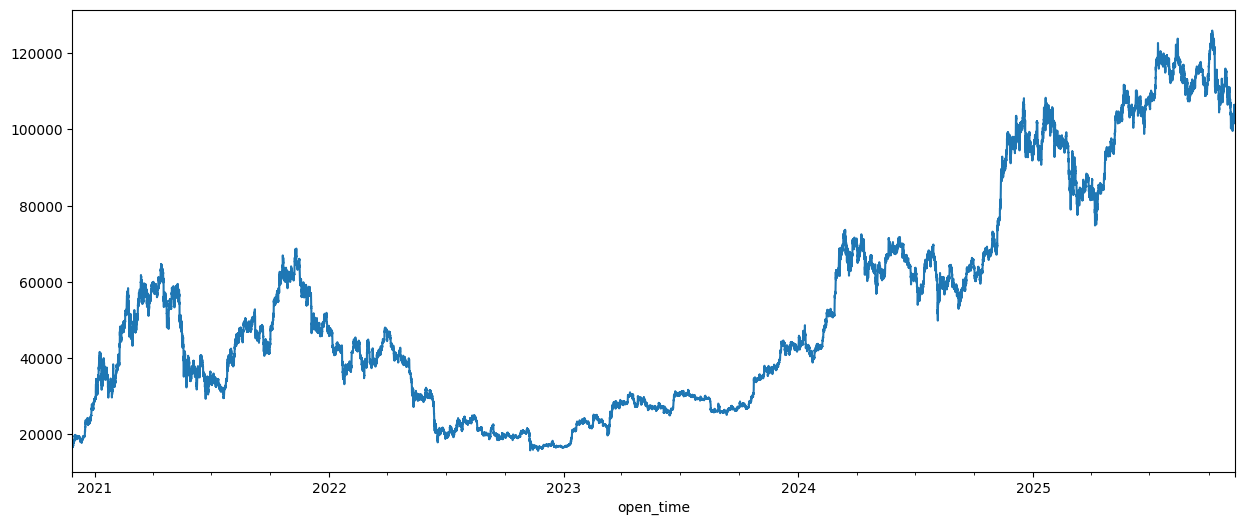

In [21]:
btcusd['close'].plot(figsize=(15, 6))

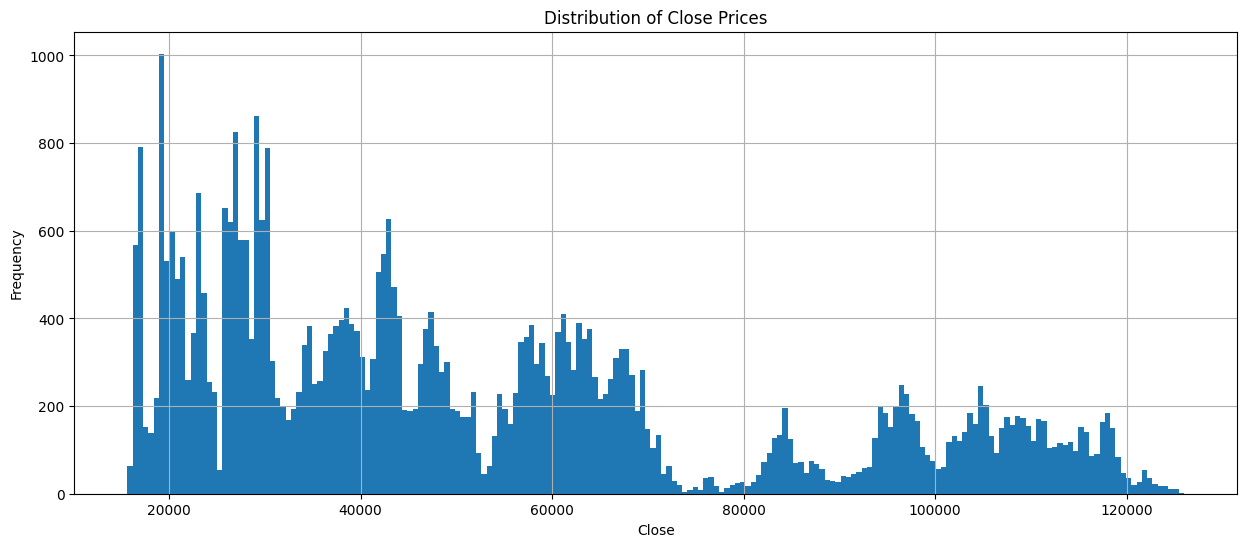

In [ ]:
# Plot Histogram of the 'close' column
import matplotlib.pyplot as plt

# This has multiple peaks, and it does not much makes sense, no usable mean
btcusd['close'].hist(bins=200, figsize=(15, 6))
plt.title("Distribution of Close Prices")
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.show()

### Differencing

In [23]:
btcusd['close_lag_1'] = btcusd['close'].shift()
btcusd['close_delta'] = btcusd['close'] - btcusd['close_lag_1']
btcusd

,open,high,low,close,volume,close_lag_1,close_delta
open_time,,,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474,NaN,NaN
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689,17400.00,-90.06
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837,17309.94,-207.56
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593,17102.38,-18.33
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,17084.05,-4.49
...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178,105435.80,331.40
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547,105767.20,189.50
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325,105956.70,-373.20


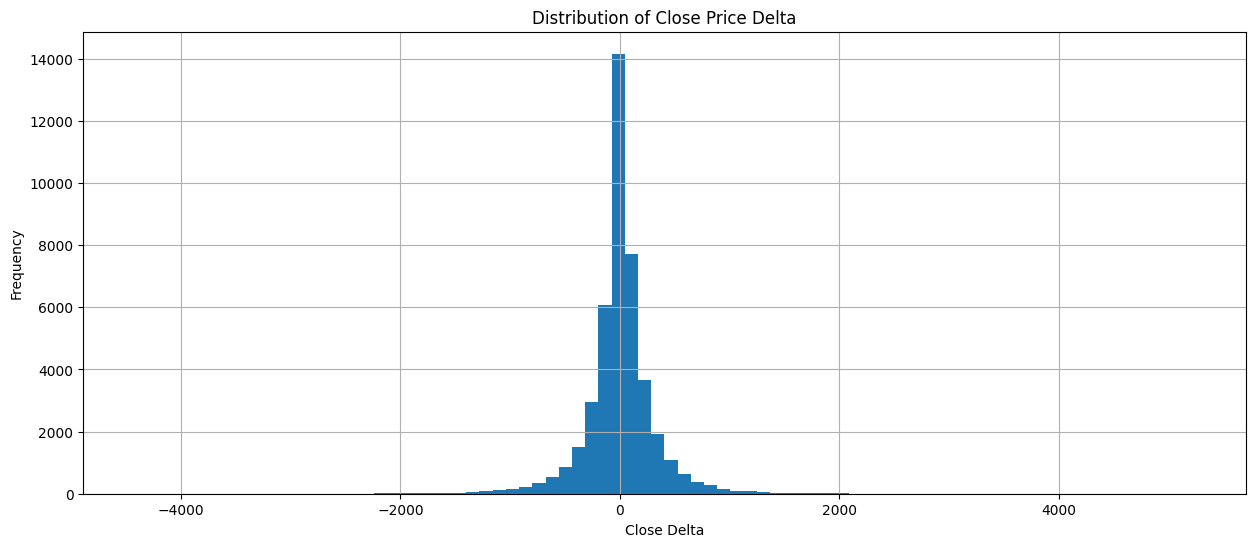

In [ ]:
# Now we are following a Central Tendency of 1 Peak.

btcusd['close_delta'].hist(bins=80, figsize=(15, 6))
plt.title("Distribution of Close Price Delta")
plt.xlabel("Close Delta")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Price moves by an average of 2 dollars per hour, with a standard deviation of 334 dollars per hour,
#  which is a very high volatility, indicating that the price can fluctuate widely in a short period of time.
btcusd['close_delta'].mean(), btcusd['close_delta'].std()

(np.float64(2.038865995994383), np.float64(334.6994054851095))

In [29]:
# We can calculate what is the probability of price moving up or down by 100 dollars in the next hour, 
# which is a significant move given the average price change and volatility.

price_move_threshold = 100

probability_up = (btcusd['close_delta'] > price_move_threshold).mean()
probability_down = (btcusd['close_delta'] < -price_move_threshold).mean()

probability_up, probability_down

(np.float64(0.27232965009208104), np.float64(0.2591850828729282))

### Stationary VS Non-Stationary

In [ ]:
# Stationary means that statistical properties of the time serties are constant over time, they never change
# It's often claimed that price differences (deltas) are stationary

# Here we can see that the mean and standard deviation of the price deltas are not constant over time, they fluctuate significantly,
# which suggests that the price deltas are not stationary.
yearly_stats = btcusd['close_delta'].resample('YE').agg(['mean', 'std'])
yearly_stats

,mean,std
open_time,,
2020-12-31,13.768391,172.361174
2021-12-31,1.970192,407.265282
2022-12-31,-3.387324,202.578210
2023-12-31,2.942511,131.701455
2024-12-31,5.832753,379.158165
2025-12-31,1.647744,462.794828


### Lags

In [33]:
btcusd['close_delta_lag_1'] = btcusd['close_delta'].shift()
btcusd['close_delta_lag_2'] = btcusd['close_delta'].shift(2)
btcusd['close_delta_lag_3'] = btcusd['close_delta'].shift(3)
btcusd['close_delta_lag_4'] = btcusd['close_delta'].shift(4)

btcusd[['close_delta', 'close_delta_lag_1', 'close_delta_lag_2', 'close_delta_lag_3', 'close_delta_lag_4']].dropna().head(10)

,close_delta,close_delta_lag_1,close_delta_lag_2,close_delta_lag_3,close_delta_lag_4
open_time,,,,,
2020-11-27 05:00:00,187.98,-4.49,-18.33,-207.56,-90.06
2020-11-27 06:00:00,19.16,187.98,-4.49,-18.33,-207.56
2020-11-27 07:00:00,-181.45,19.16,187.98,-4.49,-18.33
2020-11-27 08:00:00,-247.50,-181.45,19.16,187.98,-4.49
2020-11-27 09:00:00,-196.77,-247.50,-181.45,19.16,187.98
2020-11-27 10:00:00,262.85,-196.77,-247.50,-181.45,19.16
2020-11-27 11:00:00,-126.64,262.85,-196.77,-247.50,-181.45
2020-11-27 12:00:00,273.80,-126.64,262.85,-196.77,-247.50
2020-11-27 13:00:00,-120.92,273.80,-126.64,262.85,-196.77


### Serial Correlation

In [34]:
btcusd[['close_delta', 'close_delta_lag_1', 'close_delta_lag_2', 'close_delta_lag_3', 'close_delta_lag_4']].dropna().corr()

,close_delta,close_delta_lag_1,close_delta_lag_2,close_delta_lag_3,close_delta_lag_4
close_delta,1.000000,-0.010315,-0.007620,-0.004989,-0.004865
close_delta_lag_1,-0.010315,1.000000,-0.010312,-0.007622,-0.004987
close_delta_lag_2,-0.007620,-0.010312,1.000000,-0.010279,-0.007638
close_delta_lag_3,-0.004989,-0.007622,-0.010279,1.000000,-0.010261
close_delta_lag_4,-0.004865,-0.004987,-0.007638,-0.010261,1.000000


### Auto-Regression

First-Order Auto-Regression Model: AR(1)

In [35]:
ts = pd.DataFrame({'log_return':[-0.1, 0.2, -0.2, 0.1, -0.3, 0.3]})

# Number of rows
n = len(ts)

# Create date index ending today
dates = pd.date_range(end = pd.Timestamp.today().normalize(), periods = n, freq = 'D')

# Assign the date index
ts.index = dates
ts

,log_return
2026-05-20,-0.1
2026-05-21,0.2
2026-05-22,-0.2
2026-05-23,0.1
2026-05-24,-0.3
2026-05-25,0.3


In [38]:
ts['log_return_lag_1'] = ts['log_return'].shift()

### AR(1) Model Definition

In [39]:
# AR(1) model, where the current log return is predicted based on the previous log return

y = ts['log_return']
y_lag_1 = ts['log_return_lag_1']

weight = 0.0
bias = 0.0

y = weight * y_lag_1 + bias

### Fundamental Trading Dynamics

1) Mean Reversion
2) Momentum

### Mean Reversion

In [40]:
weight = -0.5
bias = 0.00001
ts['y_hat'] = weight * ts['log_return_lag_1'] + bias

ts

,log_return,log_return_lag_1,y_hat
2026-05-20,-0.1,NaN,NaN
2026-05-21,0.2,-0.1,0.05001
2026-05-22,-0.2,0.2,-0.09999
2026-05-23,0.1,-0.2,0.10001
2026-05-24,-0.3,0.1,-0.04999
2026-05-25,0.3,-0.3,0.15001


### Momentum

In [42]:
ts = pd.DataFrame({'log_return':[0.1, 0.2, 0.3, 0.4, -0.1, -0.2, -0.3, -0.4]})

# Number of rows
n = len(ts)

# Create date index ending today
dates = pd.date_range(end = pd.Timestamp.today().normalize(), periods = n, freq = 'D')

# Assign the date index
ts.index = dates
ts['log_return_lag_1'] = ts['log_return'].shift()
ts

,log_return,log_return_lag_1
2026-05-18,0.1,NaN
2026-05-19,0.2,0.1
2026-05-20,0.3,0.2
2026-05-21,0.4,0.3
2026-05-22,-0.1,0.4
2026-05-23,-0.2,-0.1
2026-05-24,-0.3,-0.2
2026-05-25,-0.4,-0.3


In [43]:
weight = 0.5
bias = 0.0001
ts['y_hat'] = weight * ts['log_return_lag_1'] + bias

ts

,log_return,log_return_lag_1,y_hat
2026-05-18,0.1,NaN,NaN
2026-05-19,0.2,0.1,0.0501
2026-05-20,0.3,0.2,0.1001
2026-05-21,0.4,0.3,0.1501
2026-05-22,-0.1,0.4,0.2001
2026-05-23,-0.2,-0.1,-0.0499
2026-05-24,-0.3,-0.2,-0.0999
2026-05-25,-0.4,-0.3,-0.1499
